In [41]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import copy
import numpy as np
from tensorflow.keras.datasets import fashion_mnist
from sklearn.preprocessing import StandardScaler

In [42]:
# Load Fashion MNIST dataset
(X_train_full, y_train_full), (X_test_raw, y_test_raw) = fashion_mnist.load_data()

# Flatten images from 28x28 to 784
X_train_full_flat = X_train_full.reshape(-1, 784)
X_test_flat = X_test_raw.reshape(-1, 784)

# Split training data into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full_flat,
    y_train_full,
    test_size=0.25,
    random_state=42
)

In [43]:
print("Training set shape:", X_train.shape)
print("Validation set shape:", X_val.shape)
print("Test set shape:", X_test_flat.shape)

Training set shape: (45000, 784)
Validation set shape: (15000, 784)
Test set shape: (10000, 784)


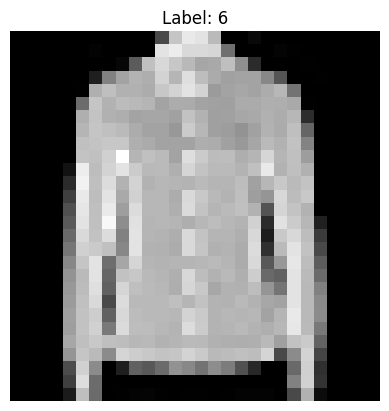

In [44]:


plt.imshow(X_train[0].reshape(28, 28), cmap='gray')
plt.title(f"Label: {y_train[0].item()}")
plt.axis('off')
plt.show()

In [45]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test_flat)


In [46]:
train_tensors = torch.tensor(X_train_scaled).float()
train_labels = torch.tensor(y_train).long()

val_tensors = torch.tensor(X_val_scaled).float()
val_labels = torch.tensor(y_val).long()

test_tensors = torch.tensor(X_test_scaled).float()
test_labels = torch.tensor(y_test_raw).long()

In [47]:
train_loader = DataLoader(TensorDataset(train_tensors, train_labels), batch_size=64, shuffle=True)
val_loader = DataLoader(TensorDataset(val_tensors, val_labels), batch_size=64, shuffle=False)
test_loader = DataLoader(TensorDataset(test_tensors, test_labels), batch_size=64, shuffle=False)

In [48]:
model = nn.Sequential(
    nn.Linear(784, 256),
    nn.BatchNorm1d(256),
    nn.ReLU(),
    nn.Dropout(0.3),

    nn.Linear(256, 128),
    nn.BatchNorm1d(128),
    nn.ReLU(),
    nn.Dropout(0.3),

    nn.Linear(128, 10)
)


In [49]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=20, gamma=0.5)


In [50]:

train_losses, val_losses = [], []
train_acc_list, val_acc_list = [], []

best_val_loss = float('inf')
patience = 5
counter = 0

for epoch in range(150):
    # TRAIN PHASE
    model.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0

    for inputs, labels in train_loader:
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        # حساب الـ Loss والـ Accuracy للـ batch الحالي
        running_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

    # تسجيل متوسط الـ Loss والـ Accuracy للـ Epoch ده
    epoch_train_loss = running_loss / total_train
    epoch_train_acc = correct_train / total_train
    train_losses.append(epoch_train_loss)
    train_acc_list.append(epoch_train_acc)

    # VALIDATION PHASE
    model.eval()
    running_val_loss = 0.0
    correct_val = 0
    total_val = 0

    with torch.no_grad():
        for inputs, labels in val_loader:
            val_outputs = model(inputs)
            v_loss = criterion(val_outputs, labels)

            running_val_loss += v_loss.item() * inputs.size(0)
            _, val_pred = torch.max(val_outputs, 1)
            total_val += labels.size(0)
            correct_val += (val_pred == labels).sum().item()

    epoch_val_loss = running_val_loss / total_val
    epoch_val_acc = correct_val / total_val
    val_losses.append(epoch_val_loss)
    val_acc_list.append(epoch_val_acc)


    print(f"Epoch {epoch} | Train Loss: {epoch_train_loss:.4f} | Val Loss: {epoch_val_loss:.4f} | Val Acc: {epoch_val_acc:.4f}")

    # تحديث الـ Scheduler
    scheduler.step()

    # EARLY STOPPING
    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        counter = 0
        best_model_wts = copy.deepcopy(model.state_dict())
    else:
        counter += 1
        if counter >= patience:
            print(f"--- Early Stopping triggered at epoch {epoch} ---")
            break


model.load_state_dict(best_model_wts)

Epoch 0 | Train Loss: 0.5469 | Val Loss: 0.3878 | Val Acc: 0.8582
Epoch 1 | Train Loss: 0.4138 | Val Loss: 0.3576 | Val Acc: 0.8679
Epoch 2 | Train Loss: 0.3802 | Val Loss: 0.3359 | Val Acc: 0.8788
Epoch 3 | Train Loss: 0.3533 | Val Loss: 0.3208 | Val Acc: 0.8797
Epoch 4 | Train Loss: 0.3382 | Val Loss: 0.3201 | Val Acc: 0.8817
Epoch 5 | Train Loss: 0.3220 | Val Loss: 0.3062 | Val Acc: 0.8860
Epoch 6 | Train Loss: 0.3101 | Val Loss: 0.3095 | Val Acc: 0.8883
Epoch 7 | Train Loss: 0.2973 | Val Loss: 0.3072 | Val Acc: 0.8857
Epoch 8 | Train Loss: 0.2896 | Val Loss: 0.3014 | Val Acc: 0.8888
Epoch 9 | Train Loss: 0.2801 | Val Loss: 0.2990 | Val Acc: 0.8891
Epoch 10 | Train Loss: 0.2748 | Val Loss: 0.2948 | Val Acc: 0.8927
Epoch 11 | Train Loss: 0.2660 | Val Loss: 0.2915 | Val Acc: 0.8938
Epoch 12 | Train Loss: 0.2668 | Val Loss: 0.2958 | Val Acc: 0.8945
Epoch 13 | Train Loss: 0.2525 | Val Loss: 0.3012 | Val Acc: 0.8927
Epoch 14 | Train Loss: 0.2469 | Val Loss: 0.2966 | Val Acc: 0.8930
Epoch

<All keys matched successfully>

In [51]:
model.eval()
correct_test = 0
total_test = 0

with torch.no_grad():
    for inputs, labels in test_loader:

        outputs = model(inputs)
        _, predicted = torch.max(outputs, 1)

        total_test += labels.size(0)
        correct_test += (predicted == labels).sum().item()

test_acc = correct_test / total_test
print(f"--- Final Test Accuracy: {test_acc:.4f} ---")

--- Final Test Accuracy: 0.8931 ---


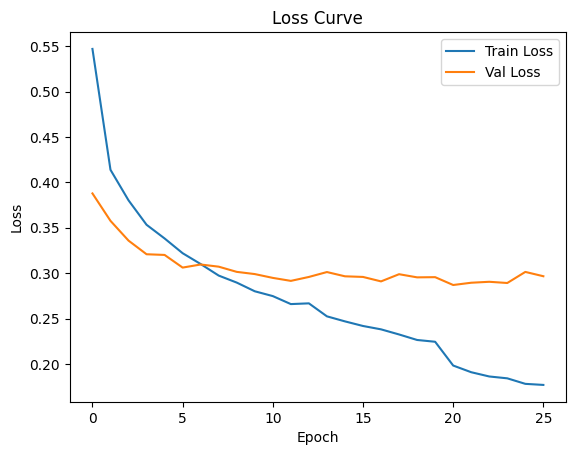

In [52]:
import matplotlib.pyplot as plt

plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Curve")
plt.legend()
plt.show()

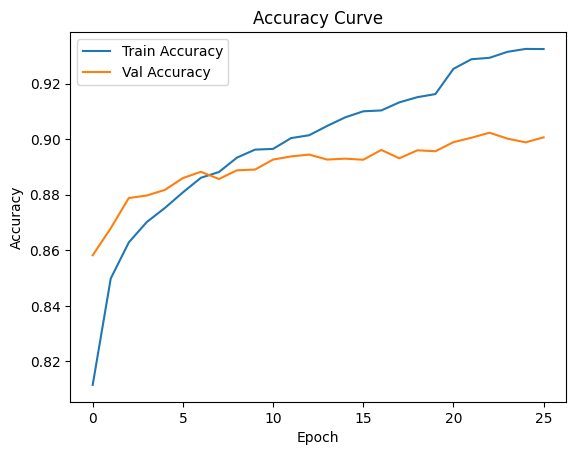

In [53]:

import matplotlib.pyplot as plt

plt.figure()

plt.plot(train_acc_list, label="Train Accuracy")
plt.plot(val_acc_list, label="Val Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy Curve")
plt.legend()

plt.show()

MODEL 2


In [54]:
model2 = nn.Sequential(

    nn.Linear(784, 256),
    nn.BatchNorm1d(256),
    nn.Tanh(),
    nn.Dropout(0.2),

    nn.Linear(256, 128),
    nn.BatchNorm1d(128),
    nn.Tanh(),
    nn.Dropout(0.2),

    nn.Linear(128, 64),
    nn.BatchNorm1d(64),
    nn.Tanh(),
    nn.Dropout(0.2),

    nn.Linear(64, 10)
)

In [55]:
criterion2 = nn.CrossEntropyLoss()

optimizer2 = optim.Adam(model2.parameters(), lr=0.001)

In [56]:
scheduler2 = optim.lr_scheduler.StepLR(optimizer2, step_size=20, gamma=0.5)

train_losses2 = []
val_losses2 = []

train_acc_list2 = []
val_acc_list2 = []

In [57]:
for epoch in range(150):

    model2.train()

    running_loss = 0
    correct_train = 0
    total_train = 0

    for inputs, labels in train_loader:
        optimizer2.zero_grad()

        outputs = model2(inputs)
        loss = criterion2(outputs, labels)

        loss.backward()
        optimizer2.step()

        running_loss += loss.item() * inputs.size(0)

        _, predicted = torch.max(outputs, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

    epoch_train_loss = running_loss / total_train
    epoch_train_acc = correct_train / total_train

    train_losses2.append(epoch_train_loss)
    train_acc_list2.append(epoch_train_acc)

    model2.eval()

    running_val_loss = 0
    correct_val = 0
    total_val = 0

    with torch.no_grad():
        for inputs, labels in val_loader:

            val_outputs = model2(inputs)
            v_loss = criterion2(val_outputs, labels)

            running_val_loss += v_loss.item() * inputs.size(0)

            _, val_pred = torch.max(val_outputs, 1)
            total_val += labels.size(0)
            correct_val += (val_pred == labels).sum().item()

    epoch_val_loss2 = running_val_loss / total_val
    epoch_val_acc2 = correct_val / total_val

    val_losses2.append(epoch_val_loss2)
    val_acc_list2.append(epoch_val_acc2)

    print(f"Epoch {epoch+1} | Train Loss: {epoch_train_loss:.4f} | Val Loss: {epoch_val_loss2:.4f} | Val Acc: {epoch_val_acc2:.4f}")

    scheduler2.step()

Epoch 1 | Train Loss: 0.5686 | Val Loss: 0.4516 | Val Acc: 0.8362
Epoch 2 | Train Loss: 0.4389 | Val Loss: 0.4047 | Val Acc: 0.8541
Epoch 3 | Train Loss: 0.4038 | Val Loss: 0.3695 | Val Acc: 0.8656
Epoch 4 | Train Loss: 0.3841 | Val Loss: 0.3484 | Val Acc: 0.8749
Epoch 5 | Train Loss: 0.3630 | Val Loss: 0.3565 | Val Acc: 0.8710
Epoch 6 | Train Loss: 0.3557 | Val Loss: 0.3402 | Val Acc: 0.8783
Epoch 7 | Train Loss: 0.3422 | Val Loss: 0.3465 | Val Acc: 0.8739
Epoch 8 | Train Loss: 0.3310 | Val Loss: 0.3397 | Val Acc: 0.8765
Epoch 9 | Train Loss: 0.3218 | Val Loss: 0.3239 | Val Acc: 0.8821
Epoch 10 | Train Loss: 0.3099 | Val Loss: 0.3352 | Val Acc: 0.8807
Epoch 11 | Train Loss: 0.3031 | Val Loss: 0.3215 | Val Acc: 0.8845
Epoch 12 | Train Loss: 0.3003 | Val Loss: 0.3264 | Val Acc: 0.8845
Epoch 13 | Train Loss: 0.2893 | Val Loss: 0.3271 | Val Acc: 0.8812
Epoch 14 | Train Loss: 0.2831 | Val Loss: 0.3117 | Val Acc: 0.8861
Epoch 15 | Train Loss: 0.2774 | Val Loss: 0.3159 | Val Acc: 0.8869
Epoc

In [58]:
model2.eval()

correct = 0
total = 0

with torch.no_grad():
    for inputs, labels in test_loader:
        outputs = model2(inputs)
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

test_acc2 = correct / total
print("Model 2 Accuracy:", test_acc2)

Model 2 Accuracy: 0.8871


MODEL3


In [59]:
model3 = nn.Sequential(

    nn.Linear(784, 512),
    nn.BatchNorm1d(512),
    nn.ReLU(),
    nn.Dropout(0.3),

    nn.Linear(512, 256),
    nn.BatchNorm1d(256),
    nn.ReLU(),
    nn.Dropout(0.3),

    nn.Linear(256, 128),
    nn.BatchNorm1d(128),
    nn.ReLU(),

    nn.Linear(128, 10)
)

In [60]:

criterion3 = nn.CrossEntropyLoss()
optimizer3 = optim.Adam(model3.parameters(), lr=0.0001)

In [61]:
train_losses3 = []
val_losses3 = []
train_acc3 = []
val_acc3 = []

best_val_loss3 = float('inf')

for epoch in range(50):

    # TRAIN
    model3.train()

    running_loss = 0
    correct = 0
    total = 0

    for inputs, labels in train_loader:

        optimizer3.zero_grad()

        outputs = model3(inputs)
        loss = criterion3(outputs, labels)

        loss.backward()
        optimizer3.step()

        running_loss += loss.item() * inputs.size(0)

        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_loss = running_loss / total
    train_acc = correct / total

    train_losses3.append(train_loss)
    train_acc3.append(train_acc)

    # VALIDATION
    model3.eval()

    val_loss_total = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for inputs, labels in val_loader:

            outputs = model3(inputs)
            loss = criterion3(outputs, labels)

            val_loss_total += loss.item() * inputs.size(0)

            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    val_loss = val_loss_total / total
    val_acc = correct / total

    val_losses3.append(val_loss)
    val_acc3.append(val_acc)

    print(f"Epoch {epoch+1} | Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}")

Epoch 1 | Train Acc: 0.7699 | Val Acc: 0.8509
Epoch 2 | Train Acc: 0.8448 | Val Acc: 0.8671
Epoch 3 | Train Acc: 0.8620 | Val Acc: 0.8770
Epoch 4 | Train Acc: 0.8715 | Val Acc: 0.8816
Epoch 5 | Train Acc: 0.8785 | Val Acc: 0.8860
Epoch 6 | Train Acc: 0.8819 | Val Acc: 0.8881
Epoch 7 | Train Acc: 0.8880 | Val Acc: 0.8883
Epoch 8 | Train Acc: 0.8913 | Val Acc: 0.8884
Epoch 9 | Train Acc: 0.8961 | Val Acc: 0.8919
Epoch 10 | Train Acc: 0.9003 | Val Acc: 0.8926
Epoch 11 | Train Acc: 0.9018 | Val Acc: 0.8912
Epoch 12 | Train Acc: 0.9050 | Val Acc: 0.8943
Epoch 13 | Train Acc: 0.9086 | Val Acc: 0.8951
Epoch 14 | Train Acc: 0.9104 | Val Acc: 0.8980
Epoch 15 | Train Acc: 0.9135 | Val Acc: 0.8955
Epoch 16 | Train Acc: 0.9155 | Val Acc: 0.8957
Epoch 17 | Train Acc: 0.9166 | Val Acc: 0.8979
Epoch 18 | Train Acc: 0.9196 | Val Acc: 0.8981
Epoch 19 | Train Acc: 0.9216 | Val Acc: 0.8977
Epoch 20 | Train Acc: 0.9228 | Val Acc: 0.8991
Epoch 21 | Train Acc: 0.9236 | Val Acc: 0.8970
Epoch 22 | Train Acc: 

In [62]:
model3.eval()

correct = 0
total = 0

with torch.no_grad():
    for inputs, labels in test_loader:
        outputs = model3(inputs)
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

test_acc3 = correct / total
print("Model 3 Accuracy:", test_acc3)

Model 3 Accuracy: 0.8944


visualization


In [63]:
print("==== FINAL COMPARISON ====")
print("Model  Accuracy:", test_acc)
print("Model 2 Accuracy:", test_acc2)
print("Model 3 Accuracy:", test_acc3)

==== FINAL COMPARISON ====
Model  Accuracy: 0.8931
Model 2 Accuracy: 0.8871
Model 3 Accuracy: 0.8944


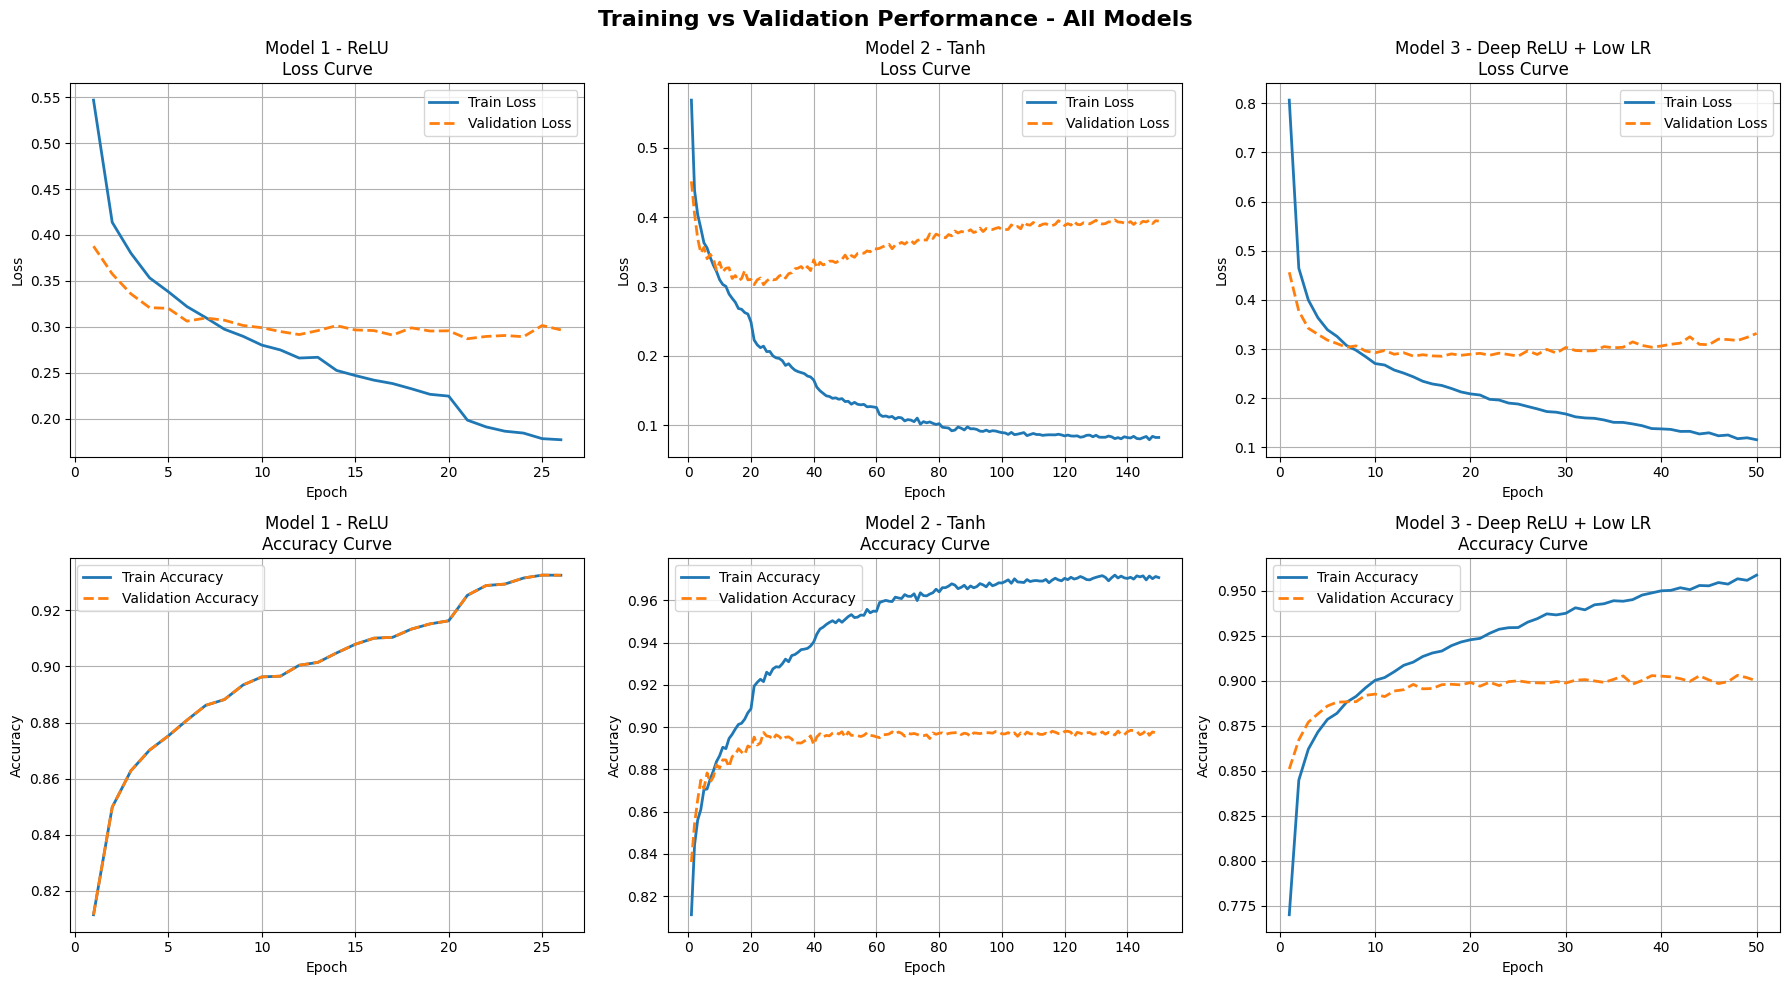

In [64]:
# ================= VISUALIZATION FOR ALL 3 MODELS =================

experiments = [
    ('Model 1 - ReLU', train_losses, val_losses, train_acc_list, train_acc_list),
    ('Model 2 - Tanh', train_losses2, val_losses2, train_acc_list2, val_acc_list2),
    ('Model 3 - Deep ReLU + Low LR', train_losses3, val_losses3, train_acc3, val_acc3),
]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

fig.suptitle(
    'Training vs Validation Performance - All Models',
    fontsize=16,
    fontweight='bold'
)

for col, (title, train_losses_exp, val_losses_exp, train_acc_exp, val_acc_exp) in enumerate(experiments):

    epochs = range(1, len(train_losses_exp) + 1)

    # ================= LOSS CURVE =================
    ax_loss = axes[0][col]

    ax_loss.plot(
        epochs,
        train_losses_exp,
        label='Train Loss',
        linewidth=2
    )

    ax_loss.plot(
        epochs,
        val_losses_exp,
        label='Validation Loss',
        linewidth=2,
        linestyle='--'
    )

    ax_loss.set_title(f'{title}\nLoss Curve')
    ax_loss.set_xlabel('Epoch')
    ax_loss.set_ylabel('Loss')
    ax_loss.legend()
    ax_loss.grid(True)

    # ================= ACCURACY CURVE =================
    ax_acc = axes[1][col]

    ax_acc.plot(
        epochs,
        train_acc_exp,
        label='Train Accuracy',
        linewidth=2
    )

    ax_acc.plot(
        epochs,
        val_acc_exp,
        label='Validation Accuracy',
        linewidth=2,
        linestyle='--'
    )

    ax_acc.set_title(f'{title}\nAccuracy Curve')
    ax_acc.set_xlabel('Epoch')
    ax_acc.set_ylabel('Accuracy')
    ax_acc.legend()
    ax_acc.grid(True)

plt.tight_layout()
plt.show()

In [65]:
import pandas as pd

results_df = pd.DataFrame({
    'Experiment': ['Model 1', 'Model 2', 'Model 3'],
    'Accuracy': [test_acc, test_acc2, test_acc3]
})

best = results_df.loc[results_df['Accuracy'].idxmax()]

print(best)

Experiment    Model 3
Accuracy       0.8944
Name: 2, dtype: object
